In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime, timedelta

# Lección 1: ANÁLISIS EXPLORATORIO DE DATOS

In [18]:
## GENERACIÓN DE DATOS (Simulación de Minimarket)
np.random.seed(42)
n_registros = 500

categorias = ['Vegetales', 'Dormitorio', 'Limpieza', 'Abarrotes', 'Lácteos']
metodos_pago = ['Efectivo', 'Tarjeta', 'Transferencia']

data = {
    'id_ticket': range(1, n_registros + 1),
    'fecha': [datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_registros)],
    'categoria': np.random.choice(categorias, n_registros),
    'metodo_pago': np.random.choice(metodos_pago, n_registros),
    # Monto: Distribución Normal (promedio 15.000, pero con varianza)
    'monto_total': np.abs(np.random.normal(15000, 8000, n_registros)).round(2),
    # Unidades: Distribución Uniforme (entre 1 y 12 productos)
    'unidades': np.random.randint(1, 13, n_registros),
    'satisfaccion_cliente': np.clip(np.random.normal(7, 1.5, n_registros), 1, 10).round(1)
}

df = pd.DataFrame(data)

# INSERTAR ERRORES PARA LIMPIEZA (IDA)
# Valores nulos aleatorios
df.loc[np.random.choice(df.index, 20), 'monto_total'] = np.nan
df.loc[np.random.choice(df.index, 10), 'categoria'] = np.nan

# Outliers (compras de "Dormitorio" muy caras que parecen errores)
df.loc[0:5, 'monto_total'] = df.loc[0:5, 'monto_total'] * 15

# Guardamos para usar en el proyecto
df.to_csv('comercio_ya_minimarket.csv', index=False)

# ---------------------------------------------------------
# ANÁLISIS INICIAL DE DATOS (IDA)
# ---------------------------------------------------------
print("--- ESTRUCTURA DE LOS DATOS ---")
print(df.info())

print("\n--- DETECCIÓN DE VALORES NULOS ---")
print(df.isnull().sum())

# Acción de limpieza: Llenar montos nulos con la mediana para no perder datos
df['monto_total'] = df['monto_total'].fillna(df['monto_total'].median())

# Eliminar filas donde no sabemos la categoría (opción de limpieza)
df.dropna(subset=['categoria'], inplace=True)

print("\n--- DATOS LIMPIOS ---")
print(f"Registros finales: {len(df)}")

--- ESTRUCTURA DE LOS DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_ticket             500 non-null    int64         
 1   fecha                 500 non-null    datetime64[ns]
 2   categoria             490 non-null    object        
 3   metodo_pago           500 non-null    object        
 4   monto_total           481 non-null    float64       
 5   unidades              500 non-null    int64         
 6   satisfaccion_cliente  500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 27.5+ KB
None

--- DETECCIÓN DE VALORES NULOS ---
id_ticket                0
fecha                    0
categoria               10
metodo_pago              0
monto_total             19
unidades                 0
satisfaccion_cliente     0
dtype: int64

--- DATOS LIMPIO

# Lección 2: CONCEPTOS BÁSICOS DE ESTADÍSTICA DESCRIPTIVA

--- Estadísticas de Ventas (Monto Total) ---
Promedio (Media): $17770
Punto Medio (Mediana): $15387
Valor más común (Moda): $15387
Desviación Estándar: $26973
Rango de Precios: $371695

Cuartiles:
0.25     9835.6425
0.50    15387.0800
0.75    19927.1450
Name: monto_total, dtype: float64

--- Análisis de Outliers ---
Límite superior para ser 'normal': $35064
Casos detectados como outliers: 8


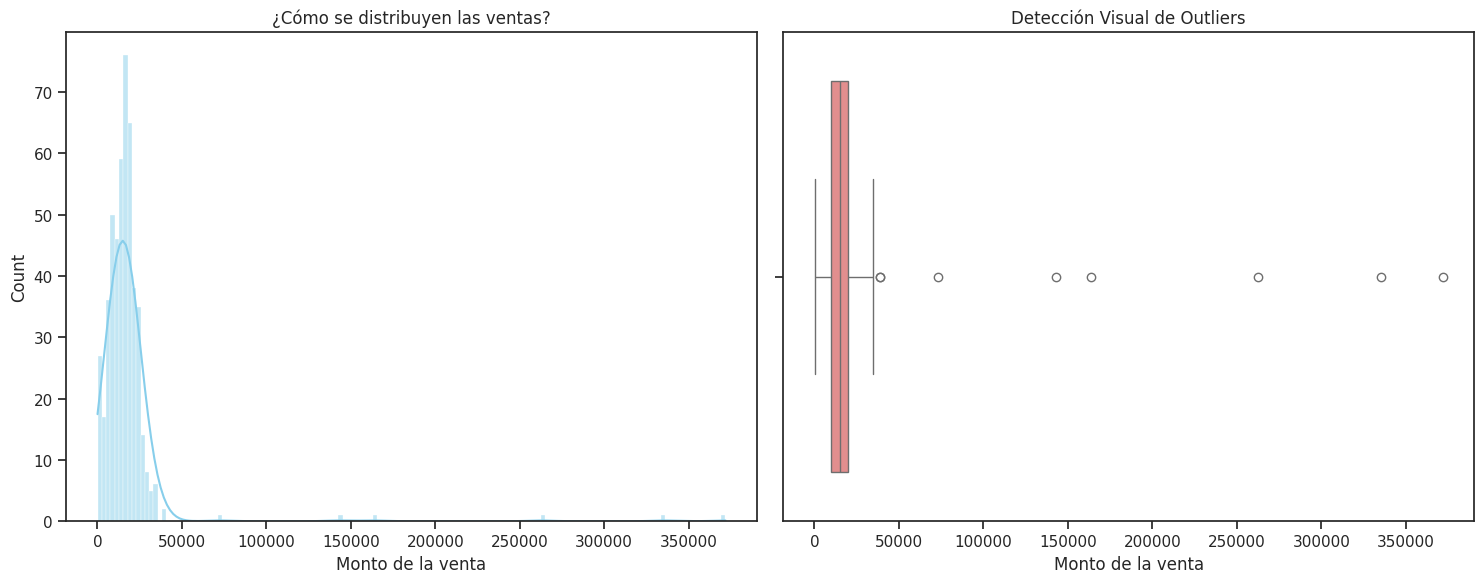

In [19]:
# Medidas de Tendencia Central
media = df['monto_total'].mean()
mediana = df['monto_total'].median()
moda = df['monto_total'].mode()[0] # Tomamos el primer valor si hay varios

# Medidas de Dispersión
varianza = df['monto_total'].var()
desviacion_estandar = df['monto_total'].std()
rango = df['monto_total'].max() - df['monto_total'].min()

# Medidas de Posición (Cuartiles y Percentiles)
cuartiles = df['monto_total'].quantile([0.25, 0.5, 0.75])
p90 = df['monto_total'].quantile(0.90) # El 10% de las ventas más altas

print(f"--- Estadísticas de Ventas (Monto Total) ---")
print(f"Promedio (Media): ${media:.0f}")
print(f"Punto Medio (Mediana): ${mediana:.0f}")
print(f"Valor más común (Moda): ${moda:.0f}")
print(f"Desviación Estándar: ${desviacion_estandar:.0f}")
print(f"Rango de Precios: ${rango:.0f}")
print(f"\nCuartiles:\n{cuartiles}")

# Identificación de Valores Atípicos (Outliers) usando IQR
Q1 = cuartiles[0.25]
Q3 = cuartiles[0.75]
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['monto_total'] < limite_inferior) | (df['monto_total'] > limite_superior)]

print(f"\n--- Análisis de Outliers ---")
print(f"Límite superior para ser 'normal': ${limite_superior:.0f}")
print(f"Casos detectados como outliers: {len(outliers)}")

# Visualización (Histograma y Boxplot)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histograma: Forma de la distribución
sns.histplot(df['monto_total'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('¿Cómo se distribuyen las ventas?')
ax[0].set_xlabel('Monto de la venta')

# Boxplot: Visualización de Outliers y Cuartiles
sns.boxplot(x=df['monto_total'], ax=ax[1], color='lightcoral')
ax[1].set_title('Detección Visual de Outliers')
ax[1].set_xlabel('Monto de la venta')

plt.tight_layout()
plt.show()

# Lección 3: CORRELACIÓN

--- COEFICIENTES DE CORRELACIÓN DE PEARSON ---
monto_total             1.000000
tiempo_en_tienda        0.983587
unidades                0.009626
satisfaccion_cliente   -0.000259
temperatura_ambiente   -0.000736
Name: monto_total, dtype: float64


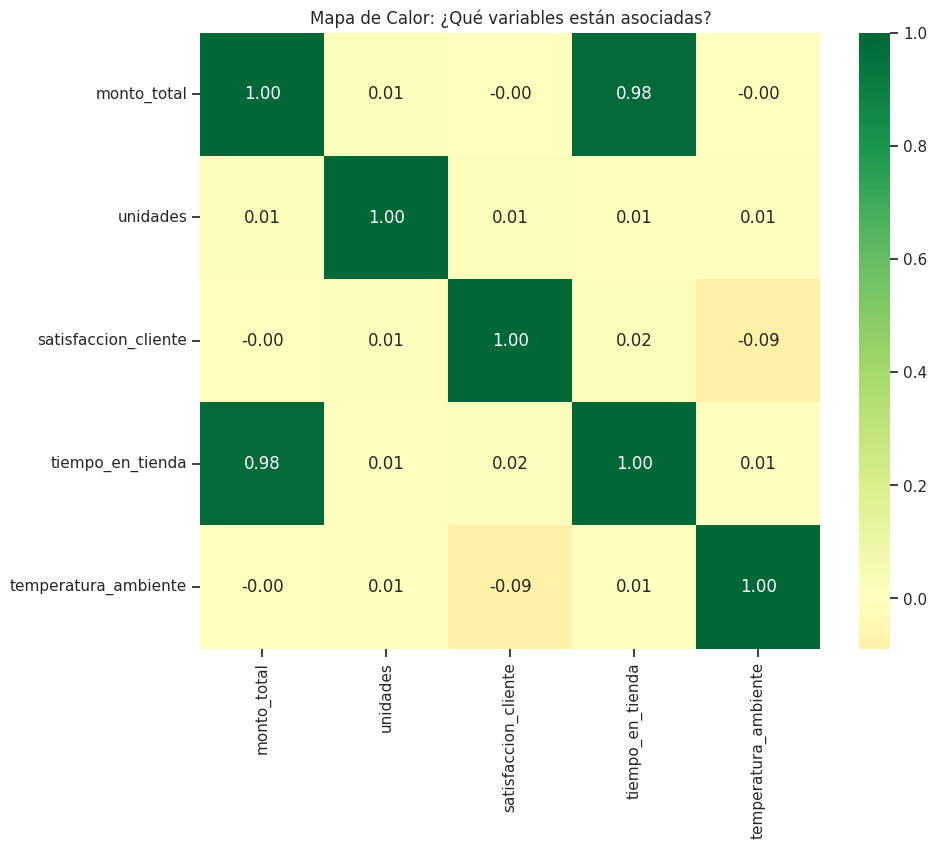

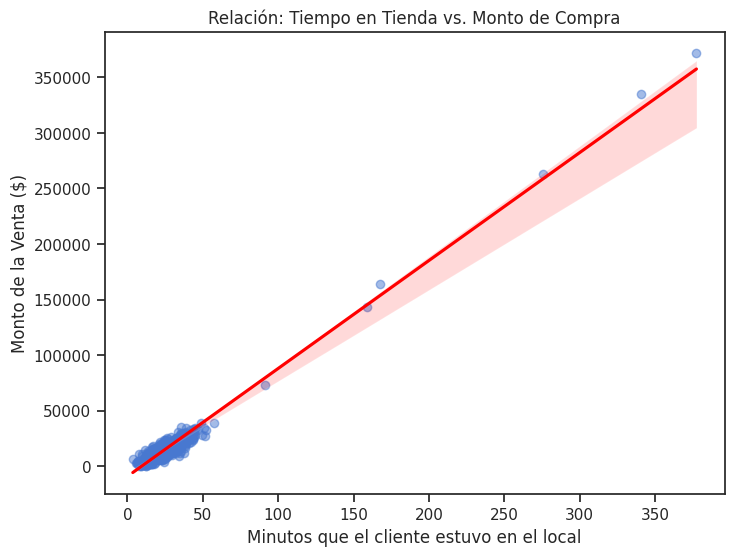

In [20]:
# Primero, vamos a simular dos variables nuevas para enriquecer el análisis
# 1. 'tiempo_en_tienda': Relación real con el gasto.
# 2. 'temperatura_ambiente': Relación espuria con las ventas (ambas suben en verano).
df['tiempo_en_tienda'] = (df['monto_total'] / 1000) + np.random.normal(10, 5, len(df))
df['temperatura_ambiente'] = np.random.normal(25, 5, len(df))

# Matriz de Correlación de Pearson (R)
# Solo tomamos variables numéricas
matriz_corr = df[['monto_total', 'unidades', 'satisfaccion_cliente', 'tiempo_en_tienda', 'temperatura_ambiente']].corr(method='pearson')

print("--- COEFICIENTES DE CORRELACIÓN DE PEARSON ---")
print(matriz_corr['monto_total'].sort_values(ascending=False))

# Visualización: Mapa de Calor (Heatmap)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Mapa de Calor: ¿Qué variables están asociadas?')
plt.show()

# Visualización: Scatterplot con Línea de Regresión
# Vamos a ver la relación entre Tiempo en Tienda y Monto Total


# [Image of scatter plots showing positive, negative, and no correlation]

plt.figure(figsize=(8, 6))
sns.regplot(x='tiempo_en_tienda', y='monto_total', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación: Tiempo en Tienda vs. Monto de Compra')
plt.xlabel('Minutos que el cliente estuvo en el local')
plt.ylabel('Monto de la Venta ($)')
plt.show()

# Lección 4: REGRESIONES LINEALES

--- RESULTADOS DEL MODELO DE REGRESIÓN ---
Coeficiente de Determinación (R2): 0.9679
R2 Ajustado: 0.9677
Error Medio Absoluto (MAE): $3869.86
Raíz del Error Cuadrático Medio (RMSE): $4826.78

--- RESUMEN DETALLADO (Statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     4887.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:35:36   Log-Likelihood:                -4851.4
No. Observations:                 490   AIC:                             9711.
Df Residuals:                     486   BIC:                             9728.
Df Model:                           3                                         
Covariance Type:            nonrobust                    

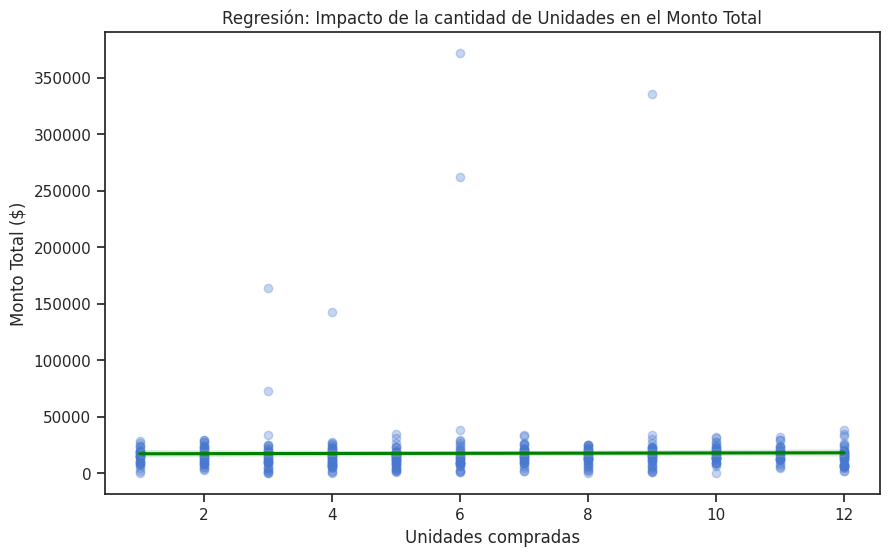

In [21]:
## Preparación de variables
# Variable Dependiente (Y): Lo que queremos explicar (el monto de la venta)
Y = df['monto_total']

# Variables Independientes (X): Lo que creemos que causa el gasto
# Usaremos: unidades compradas, satisfacción y el tiempo que estuvieron
X = df[['unidades', 'satisfaccion_cliente', 'tiempo_en_tienda']]

# Importante: Statsmodels necesita que agreguemos explícitamente la constante (el intercepto beta_0)
X = sm.add_constant(X)

# Ajuste del Modelo de Regresión Lineal Múltiple (OLS)
modelo = sm.OLS(Y, X).fit()

# Métricas de Evaluación
predicciones = modelo.predict(X)
mae = mean_absolute_error(Y, predicciones)
mse = mean_squared_error(Y, predicciones)
rmse = np.sqrt(mse)
r2 = modelo.rsquared
r2_adj = modelo.rsquared_adj

print("--- RESULTADOS DEL MODELO DE REGRESIÓN ---")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")
print(f"R2 Ajustado: {r2_adj:.4f}")
print(f"Error Medio Absoluto (MAE): ${mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:.2f}")

# Evaluación de Significancia (P-values) y Coeficientes
print("\n--- RESUMEN DETALLADO (Statsmodels) ---")
print(modelo.summary())

# Visualización de la Regresión (Seaborn)
plt.figure(figsize=(10, 6))
sns.regplot(x=df['unidades'], y=df['monto_total'], scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title('Regresión: Impacto de la cantidad de Unidades en el Monto Total')
plt.xlabel('Unidades compradas')
plt.ylabel('Monto Total ($)')
plt.show()

# Lección 5: ANÁLISIS VISUAL DE DATOS

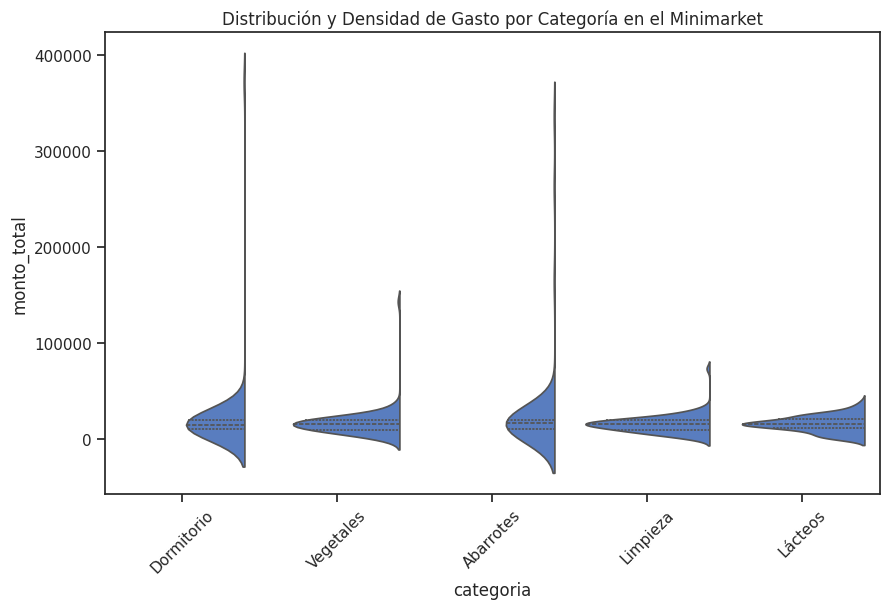

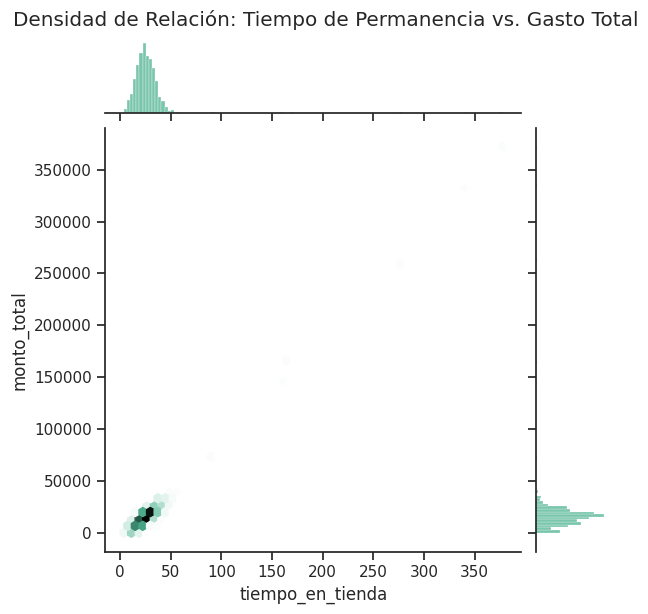

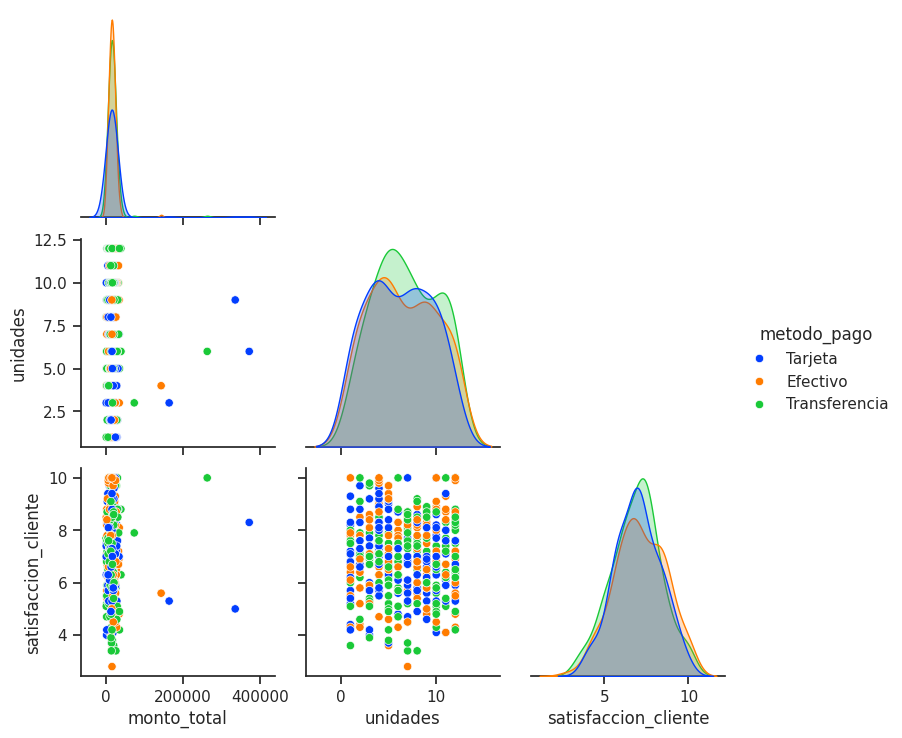

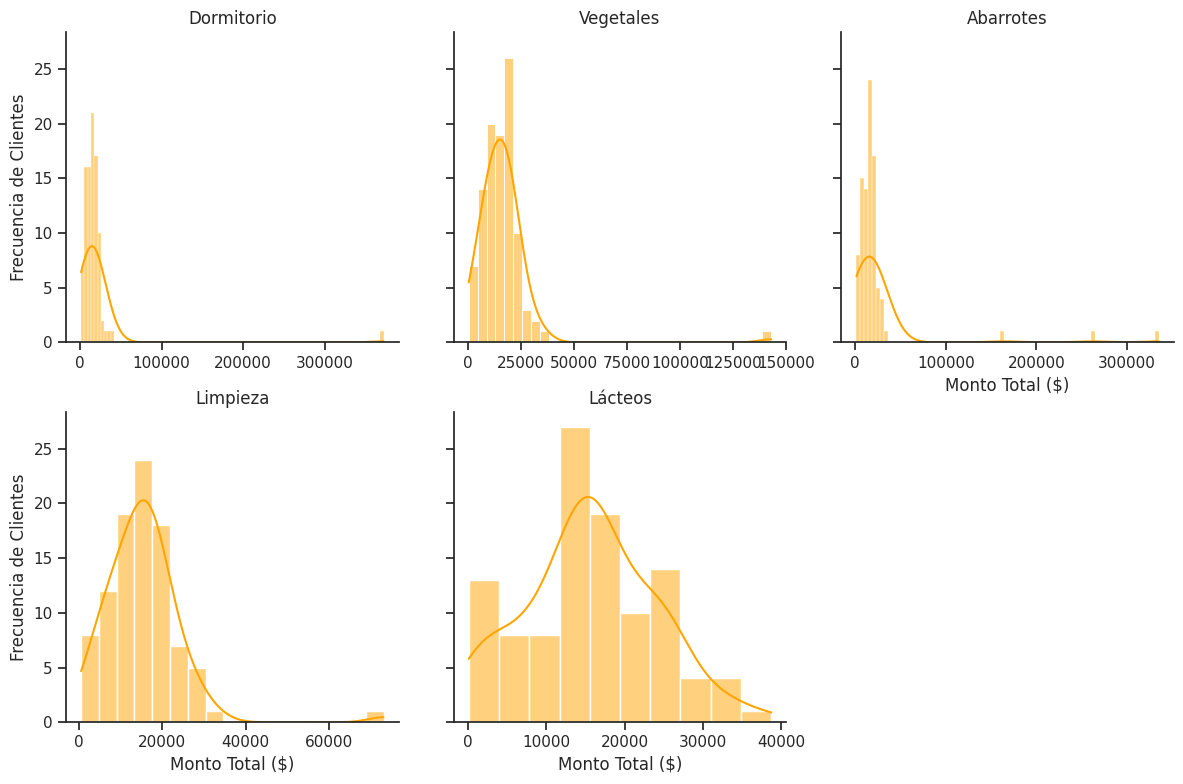

In [22]:
# Ajuste de Estilo y Colores
sns.set_theme(style="ticks", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Violin Plot: Comparando distribuciones por categoría
# Es mejor que el boxplot porque muestra la "densidad" (donde hay más gente)

plt.figure(figsize=(10, 6))
sns.violinplot(x='categoria', y='monto_total', data=df, inner="quartile", split=True)
plt.title('Distribución y Densidad de Gasto por Categoría en el Minimarket')
plt.xticks(rotation=45)
plt.show()

# JointPlot: Relación entre dos variables y sus distribuciones individuales
# Ideal para ver el "comportamiento conjunto" de tiempo vs gasto

sns.jointplot(x='tiempo_en_tienda', y='monto_total', data=df, kind="hex", color="#4CB391")
plt.suptitle('Densidad de Relación: Tiempo de Permanencia vs. Gasto Total', y=1.02)
plt.show()

# PairPlot: La "foto general" del negocio
# Muestra todas las relaciones numéricas de un vistazo, segmentadas por método de pago

sns.pairplot(df[['monto_total', 'unidades', 'satisfaccion_cliente', 'metodo_pago']],
             hue='metodo_pago', corner=True, palette='bright')
plt.show()

# FacetGrid: Segmentación avanzada (El "Power Move")
# Vamos a ver cómo se distribuye el gasto en cada categoría por separado

g = sns.FacetGrid(df, col="categoria", col_wrap=3, height=4, sharex=False)
g.map(sns.histplot, "monto_total", color="orange", kde=True)
g.set_axis_labels("Monto Total ($)", "Frecuencia de Clientes")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

# Lección 6: LIBRERÍA MATPLOTLIB

/tmp/ipython-input-3870081626.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='metodo_pago', y='monto_total', data=df, ax=axes[1, 0], palette='Pastel1')


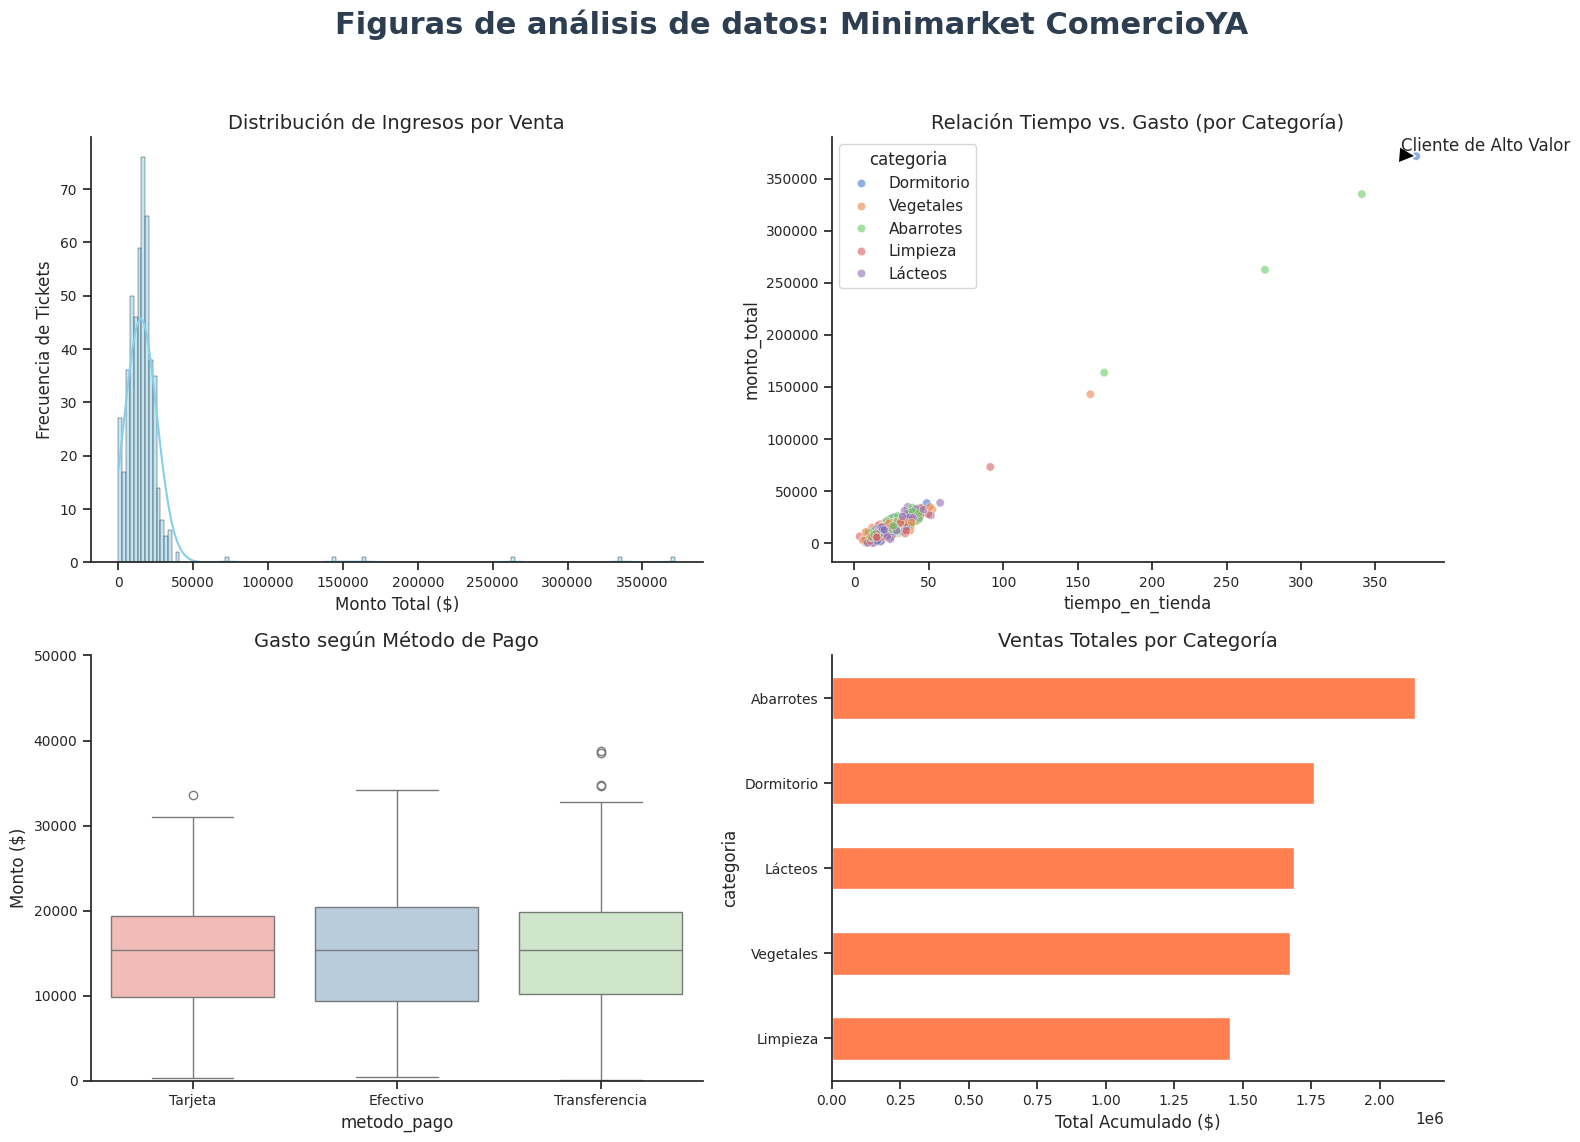

In [24]:
## Crear la Figura y los Subplots (Cuadrícula 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figuras de análisis de datos: Minimarket ComercioYA',
             fontsize=22, fontweight='bold', color='#2c3e50')

# --- Subplot 1: Histograma Personalizado ---
sns.histplot(df['monto_total'], kde=True, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribución de Ingresos por Venta', fontsize=14)
axes[0, 0].set_xlabel('Monto Total ($)', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia de Tickets', fontsize=12)

# --- Subplot 2: Gráfico de Dispersión con Anotaciones ---
sns.scatterplot(x='tiempo_en_tienda', y='monto_total', data=df,
                hue='categoria', ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title('Relación Tiempo vs. Gasto (por Categoría)', fontsize=14)
# Anotación: Señalando un posible outlier o tendencia
axes[0, 1].annotate('Cliente de Alto Valor', xy=(df['tiempo_en_tienda'].max(), df['monto_total'].max()),
                    xytext=(df['tiempo_en_tienda'].max()-10, df['monto_total'].max()+5000),
                    arrowprops=dict(facecolor='black', shrink=0.05))

# --- Subplot 3: Boxplot con Ajuste de Límites (Ticks) ---
sns.boxplot(x='metodo_pago', y='monto_total', data=df, ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_title('Gasto según Método de Pago', fontsize=14)
axes[1, 0].set_ylim(0, 50000) # Ajustamos límites para ignorar outliers extremos en la visual
axes[1, 0].set_ylabel('Monto ($)', fontsize=12)

# --- Subplot 4: Gráfico de Barras con Etiquetas de Datos ---
ventas_por_cat = df.groupby('categoria')['monto_total'].sum().sort_values()
ventas_por_cat.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Ventas Totales por Categoría', fontsize=14)
axes[1, 1].set_xlabel('Total Acumulado ($)', fontsize=12)

## Personalización General (Leyendas, Ticks y Layout)
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Personalizar los ticks (números en los ejes)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que el título principal no choque

## Exportar el archivo en formato profesional
plt.savefig('informe_final_comercioya_leonardo.png', dpi=300, bbox_inches='tight')
plt.savefig('informe_final_comercioya_leonardo.pdf') # Formato vectorial para documentos

plt.show()